In [1]:
import sys
sys.path.append("..")

import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
sns.set_theme(style="whitegrid")
PROC_DIR = Path("../data/processed")

d = joblib.load(PROC_DIR / "splits.joblib")
Xtr, Xte = d["Xtr"], d["Xte"]
y_train, y_test = d["y_train_q"], d["y_test_q"]

In [3]:
for C in [0.1, 0.3, 0.5, 1.0, 2.0]:
    m = LinearSVC(class_weight="balanced", C=C).fit(Xtr, y_train)
    p = m.predict(Xte)
    print(f"C={C:<5} acc={accuracy_score(y_test,p):.4f}  macroF1={f1_score(y_test,p,average='macro'):.4f}")

C=0.1   acc=0.4570  macroF1=0.4196
C=0.3   acc=0.4990  macroF1=0.4717
C=0.5   acc=0.5191  macroF1=0.4906
C=1.0   acc=0.5414  macroF1=0.5229
C=2.0   acc=0.5498  macroF1=0.5371


In [4]:
MERGE = {
    "Technical Support": "Technical Support",
    "Product Support":   "Technical Support",
    "IT Support":        "Technical Support",
}

y_train_m = y_train.replace(MERGE)
y_test_m  = y_test.replace(MERGE)

print(y_train_m.value_counts(), "\n")

m = LinearSVC(class_weight="balanced", C=0.5).fit(Xtr, y_train_m)
pred_m = m.predict(Xte)

print(f"MERGED  ({y_train_m.nunique()} classes): "
      f"acc={accuracy_score(y_test_m, pred_m):.4f}  "
      f"macroF1={f1_score(y_test_m, pred_m, average='macro'):.4f}")
print(f"ORIGINAL (10 classes): acc=0.5191  macroF1=0.4906\n")
print(classification_report(y_test_m, pred_m, zero_division=0))

queue
Technical Support                  5621
Customer Service                   1485
Billing and Payments               1034
Returns and Exchanges               464
Service Outages and Maintenance     354
Sales and Pre-Sales                 264
Human Resources                     164
General Inquiry                     134
Name: count, dtype: int64 

MERGED  (8 classes): acc=0.6917  macroF1=0.5443
ORIGINAL (10 classes): acc=0.5191  macroF1=0.4906

                                 precision    recall  f1-score   support

           Billing and Payments       0.74      0.78      0.76       259
               Customer Service       0.43      0.39      0.41       371
                General Inquiry       0.52      0.35      0.42        34
                Human Resources       0.57      0.51      0.54        41
          Returns and Exchanges       0.44      0.44      0.44       116
            Sales and Pre-Sales       0.38      0.38      0.38        66
Service Outages and Maintenance    

In [5]:
maj = y_train_m.mode()[0]
print(f"New majority baseline: {accuracy_score(y_test_m, [maj]*len(y_test_m)):.4f}")

New majority baseline: 0.5905


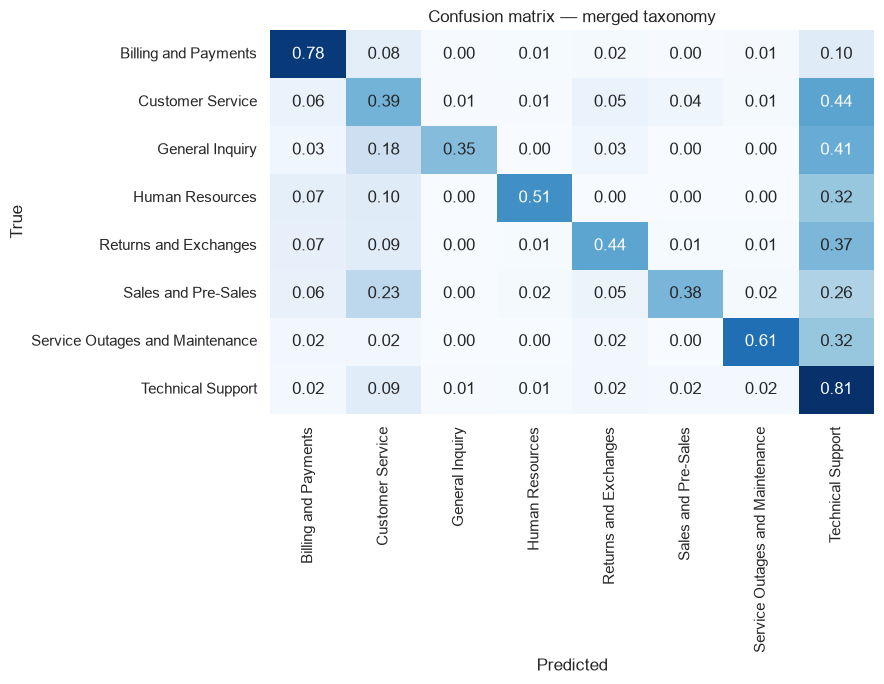

In [6]:
labels = sorted(y_test_m.unique())
cm = confusion_matrix(y_test_m, pred_m, labels=labels, normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix — merged taxonomy")
plt.tight_layout(); plt.show()

In [7]:
for C in [2.0, 4.0, 8.0, 16.0]:
    m = LinearSVC(class_weight="balanced", C=C, max_iter=5000).fit(Xtr, y_train)
    p = m.predict(Xte)
    print(f"C={C:<5} acc={accuracy_score(y_test,p):.4f}  macroF1={f1_score(y_test,p,average='macro'):.4f}")

C=2.0   acc=0.5498  macroF1=0.5371
C=4.0   acc=0.5464  macroF1=0.5310
C=8.0   acc=0.5498  macroF1=0.5313
C=16.0  acc=0.5489  macroF1=0.5294


In [8]:
BEST_C = 2.0

final_q = LinearSVC(class_weight="balanced", C=BEST_C, max_iter=5000)
final_q.fit(Xtr, y_train)
pred = final_q.predict(Xte)

print(f"FINAL department model — C={BEST_C}")
print(f"accuracy={accuracy_score(y_test,pred):.4f}  (baseline 0.286)")
print(f"macro-F1={f1_score(y_test,pred,average='macro'):.4f}\n")
print(classification_report(y_test, pred, zero_division=0))

FINAL department model — C=2.0
accuracy=0.5498  (baseline 0.286)
macro-F1=0.5371

                                 precision    recall  f1-score   support

           Billing and Payments       0.75      0.79      0.77       259
               Customer Service       0.46      0.49      0.47       371
                General Inquiry       0.59      0.38      0.46        34
                Human Resources       0.56      0.61      0.58        41
                     IT Support       0.48      0.47      0.47       278
                Product Support       0.51      0.48      0.49       446
          Returns and Exchanges       0.46      0.44      0.45       116
            Sales and Pre-Sales       0.49      0.39      0.44        66
Service Outages and Maintenance       0.63      0.65      0.64        88
              Technical Support       0.58      0.60      0.59       682

                       accuracy                           0.55      2381
                      macro avg       0.

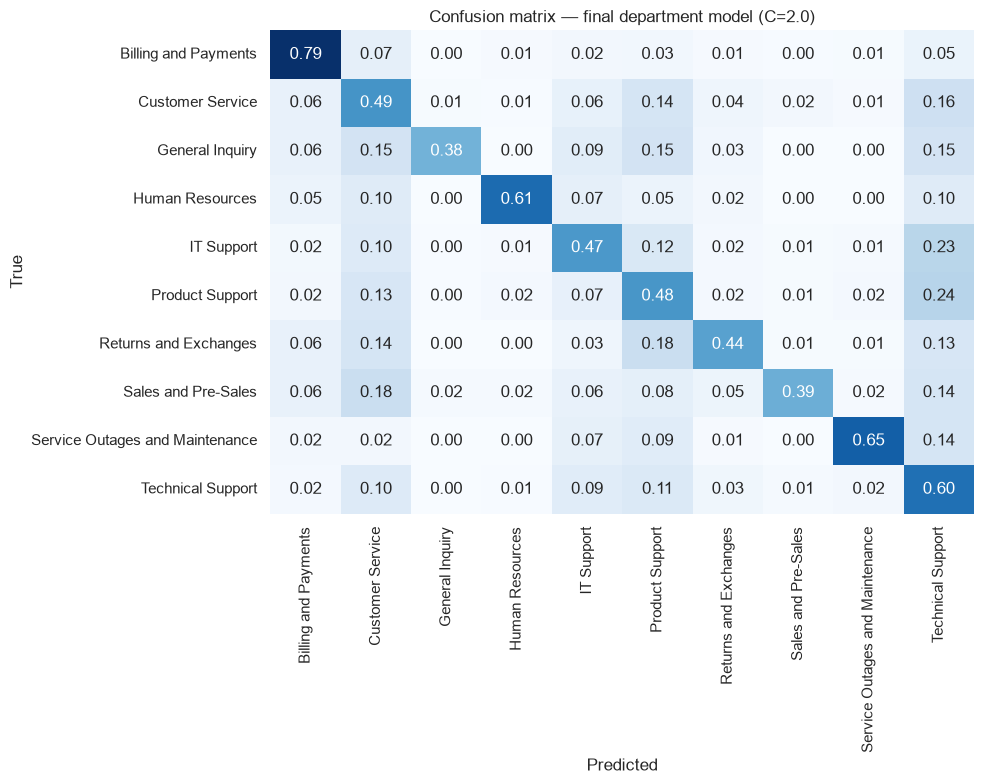

In [9]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, pred, labels=labels, normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion matrix — final department model (C={BEST_C})")
plt.tight_layout(); plt.show()

In [10]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_q = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", C=BEST_C, max_iter=5000),
    method="sigmoid", cv=5
)
calibrated_q.fit(Xtr, y_train)

pred_c = calibrated_q.predict(Xte)
print(f"Calibrated: acc={accuracy_score(y_test,pred_c):.4f}  "
      f"macroF1={f1_score(y_test,pred_c,average='macro'):.4f}")

proba = calibrated_q.predict_proba(Xte[:3])
for i, row in enumerate(proba):
    top = np.argsort(row)[-3:][::-1]
    print(f"\nTicket {i}: " + ", ".join(f"{calibrated_q.classes_[j]} {row[j]:.2f}" for j in top))

Calibrated: acc=0.5523  macroF1=0.5218

Ticket 0: Technical Support 0.62, Product Support 0.12, Customer Service 0.12

Ticket 1: IT Support 0.29, Technical Support 0.28, Human Resources 0.21

Ticket 2: Product Support 0.45, Technical Support 0.29, Customer Service 0.13


In [11]:
joblib.dump(calibrated_q, "../models/queue_classifier.joblib")
print("Saved queue_classifier.joblib")

Saved queue_classifier.joblib
